In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(r"/Users/nasreenkhalid/Desktop/Final_Project_Data.csv")

In [3]:
df

,cohort_month,user_month,active_users,cohort_size,retention_rate
0,2023-01-01,0,389,389,100.00
1,2023-01-01,1,388,389,99.74
2,2023-01-01,2,344,389,88.43
3,2023-01-01,3,300,389,77.12
4,2023-01-01,4,243,389,62.47
...,...,...,...,...,...
85,2023-11-01,0,2798,2798,100.00
86,2023-11-01,1,2782,2798,99.43
87,2023-11-01,2,2038,2798,72.84
88,2023-12-01,0,1843,1843,100.00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cohort_month    90 non-null     str    
 1   user_month      90 non-null     int64  
 2   active_users    90 non-null     int64  
 3   cohort_size     90 non-null     int64  
 4   retention_rate  90 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 3.6 KB


In [5]:
df['cohort_month'] = pd.to_datetime(df['cohort_month'])
df['user_month'] = df['user_month'].astype(int)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   cohort_month    90 non-null     datetime64[us]
 1   user_month      90 non-null     int64         
 2   active_users    90 non-null     int64         
 3   cohort_size     90 non-null     int64         
 4   retention_rate  90 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 3.6 KB


In [11]:
df['churn_rate'] = df['retention_rate']-1

In [8]:
df.head(5)

,cohort_month,user_month,active_users,cohort_size,retention_rate,churn_rate
0,2023-01-01,0,389,389,100.00,-99.00
1,2023-01-01,1,388,389,99.74,-98.74
2,2023-01-01,2,344,389,88.43,-87.43
3,2023-01-01,3,300,389,77.12,-76.12
4,2023-01-01,4,243,389,62.47,-61.47


In [9]:
df.head(10)

,cohort_month,user_month,active_users,cohort_size,retention_rate,churn_rate
0,2023-01-01,0,389,389,100.00,-99.00
1,2023-01-01,1,388,389,99.74,-98.74
2,2023-01-01,2,344,389,88.43,-87.43
3,2023-01-01,3,300,389,77.12,-76.12
4,2023-01-01,4,243,389,62.47,-61.47
5,2023-01-01,5,185,389,47.56,-46.56
6,2023-01-01,6,141,389,36.25,-35.25
7,2023-01-01,7,87,389,22.37,-21.37
8,2023-01-01,8,55,389,14.14,-13.14
9,2023-01-01,9,29,389,7.46,-6.46


In [10]:
df.head(12)

,cohort_month,user_month,active_users,cohort_size,retention_rate,churn_rate
0,2023-01-01,0,389,389,100.00,-99.00
1,2023-01-01,1,388,389,99.74,-98.74
2,2023-01-01,2,344,389,88.43,-87.43
3,2023-01-01,3,300,389,77.12,-76.12
4,2023-01-01,4,243,389,62.47,-61.47
5,2023-01-01,5,185,389,47.56,-46.56
6,2023-01-01,6,141,389,36.25,-35.25
7,2023-01-01,7,87,389,22.37,-21.37
8,2023-01-01,8,55,389,14.14,-13.14
9,2023-01-01,9,29,389,7.46,-6.46


In [16]:
df['churn_rate'] = 100 - df['retention_rate']

In [17]:
df.head(5)

,cohort_month,user_month,active_users,cohort_size,retention_rate,churn_rate
0,2023-01-01,0,389,389,100.00,0.00
1,2023-01-01,1,388,389,99.74,0.26
2,2023-01-01,2,344,389,88.43,11.57
3,2023-01-01,3,300,389,77.12,22.88
4,2023-01-01,4,243,389,62.47,37.53


In [18]:
cohort = df[df['cohort_month'] == '2023-01-01']

In [21]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


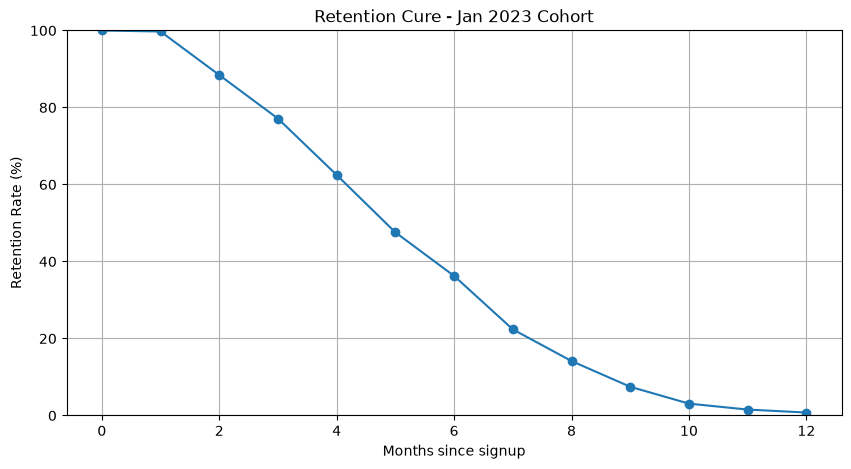

In [24]:
plt.figure(figsize=(10,5))
plt.plot(cohort['user_month'], cohort['retention_rate'], marker="o")
plt.title("Retention Curve - Jan 2023 Cohort")
plt.xlabel("Months since signup")
plt.ylabel("Retention Rate (%)")
plt.ylim(0,100)
plt.grid(True)

plt.show()

In [23]:
print(cohort['user_month'].unique())
print(cohort.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
(13, 6)


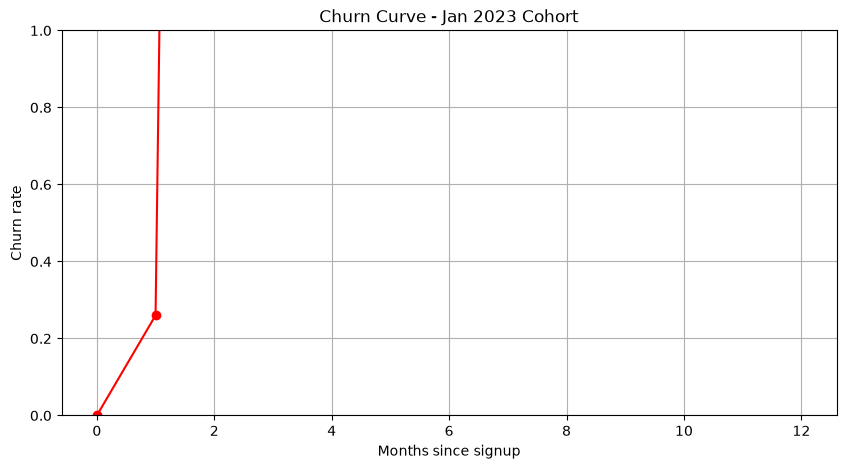

In [25]:
plt.figure(figsize=(10,5))
plt.plot(cohort['user_month'], cohort['churn_rate'], marker="o", color="red")
plt.title("Churn Curve - Jan 2023 Cohort")
plt.xlabel("Months since signup")
plt.ylabel("Churn rate")
plt.ylim(0,1)
plt.grid(True)

plt.show()

In [26]:
cohorts_to_compare = ['2023-01-01','2023-02-01']

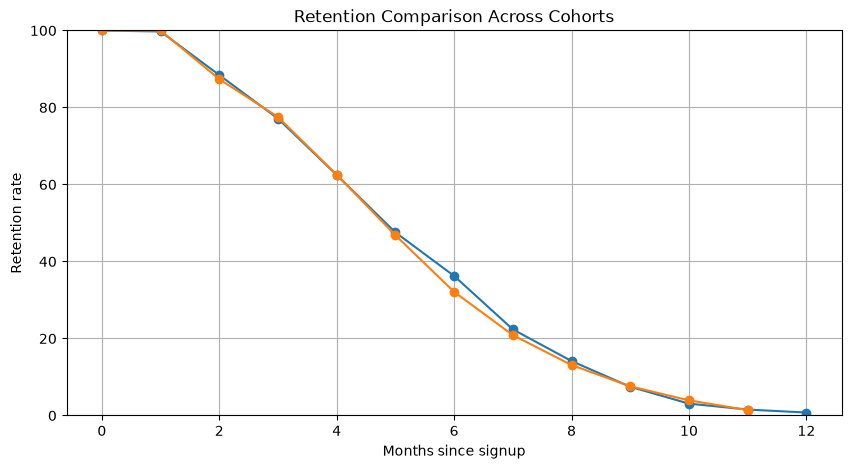

In [28]:
plt.figure(figsize=(10,5))
for c in cohorts_to_compare:
    temp = df[df['cohort_month'] == c]
    plt.plot(temp['user_month'], temp['retention_rate'], marker="o", label = c)
plt.title("Retention Comparison Across Cohorts")
plt.xlabel("Months since signup")
plt.ylabel("Retention rate")
plt.ylim(0,100)
plt.grid(True)

plt.show()

In [29]:
import seaborn as sns
import matplotlib as plt

ModuleNotFoundError: No module named 'seaborn'

In [30]:
import sys
!{sys.executable} -m pip install seaborn

In [31]:
import seaborn as sns

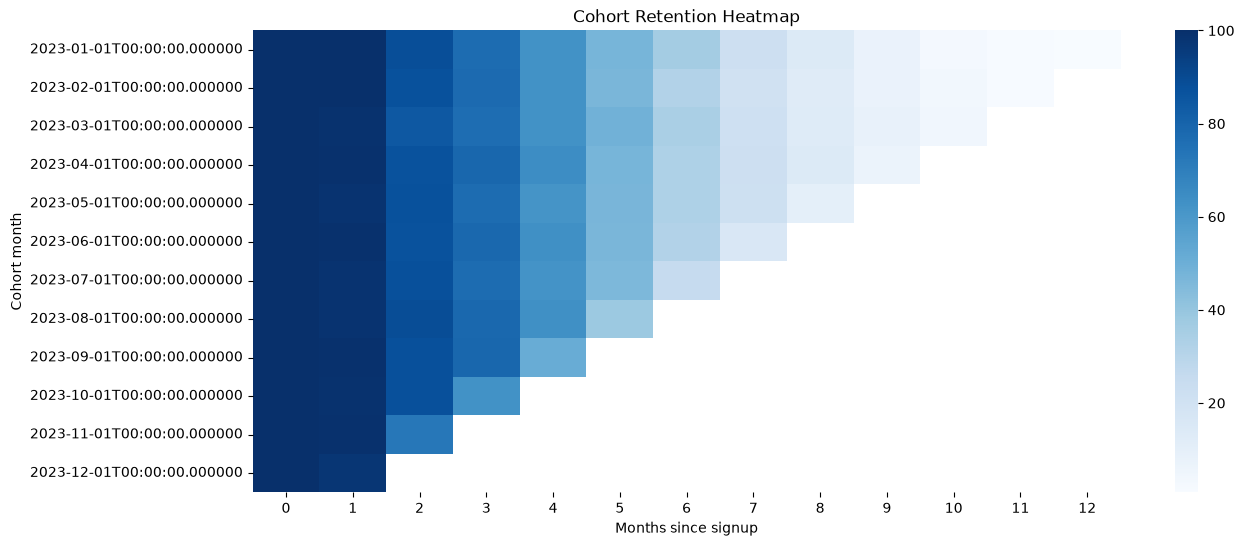

In [32]:
pivot = df.pivot(
    index="cohort_month",
    columns="user_month",
    values="retention_rate"
)

plt.figure(figsize=(14,6))

sns.heatmap(pivot, cmap="Blues", annot=False)

plt.title("Cohort Retention Heatmap")
plt.xlabel("Months since signup")
plt.ylabel("Cohort month")

plt.show()

In [33]:
df.groupby('user_month')['retention_rate'].mean()

user_month
0     100.000000
1      99.046667
2      86.102727
3      76.223000
4      61.596667
5      46.147500
6      32.424286
7      20.788333
8      12.942000
9       7.542500
10      3.850000
11      1.470000
12      0.770000
Name: retention_rate, dtype: float64

In [34]:
df.groupby('user_month')['churn_rate'].mean()

user_month
0      0.000000
1      0.953333
2     13.897273
3     23.777000
4     38.403333
5     53.852500
6     67.575714
7     79.211667
8     87.058000
9     92.457500
10    96.150000
11    98.530000
12    99.230000
Name: churn_rate, dtype: float64